C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21676\319409774.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
d:\randomstuff\clone_git\GoogleMapReviews_Dataset\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(444, 7)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4637.23it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


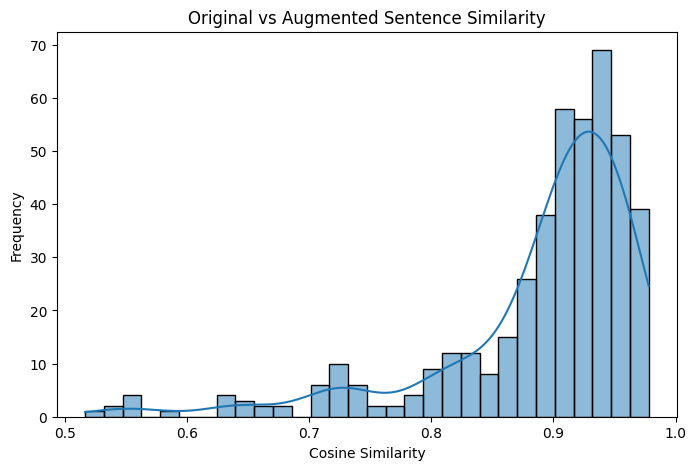

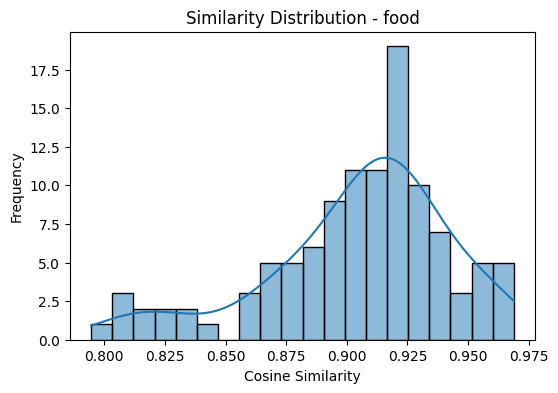

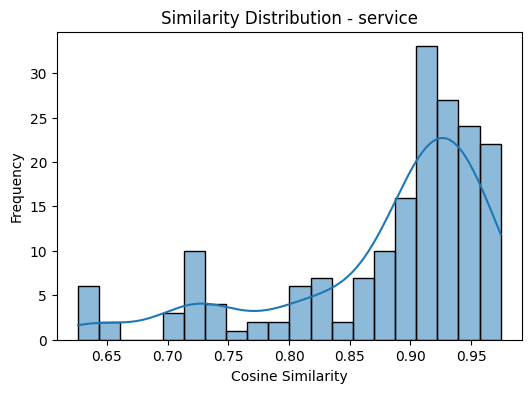

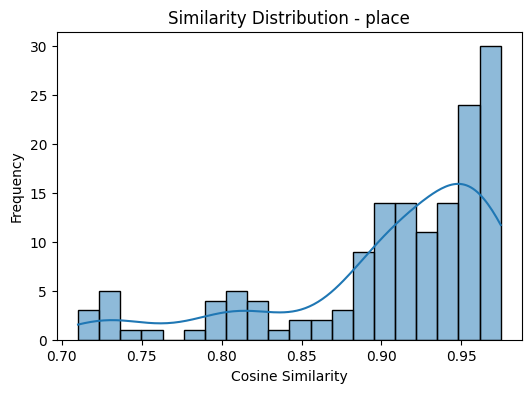

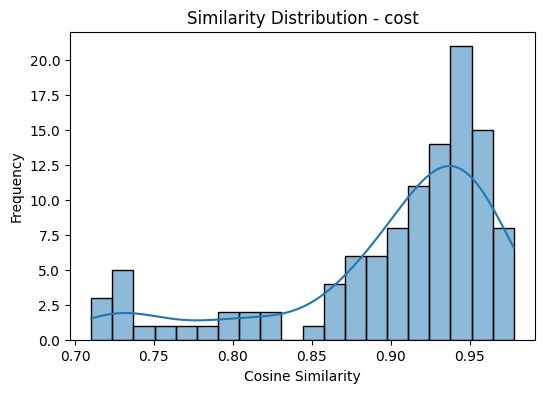

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import glob

files = glob.glob("reviews_augmented_20260312*.csv")

df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

print(df.shape)
# expected columns: original,augmented,food,service,place,cost

# 2. Load embedding model
model = SentenceTransformer("all-MiniLM-L6-v2")

# 3. Generate embeddings
orig_embeddings = model.encode(df["original"].astype(str).tolist())
aug_embeddings = model.encode(df["augmented"].astype(str).tolist())

# 4. Compute similarity
similarities = [
    cosine_similarity([o], [a])[0][0]
    for o, a in zip(orig_embeddings, aug_embeddings)
]

df["similarity"] = similarities

# 5. Save result with similarity
df.to_csv("augmented_with_similarity.csv", index=False)

# 6. Plot overall similarity distribution
plt.figure(figsize=(8,5))
sns.histplot(df["similarity"], bins=30, kde=True)
plt.title("Original vs Augmented Sentence Similarity")
plt.xlabel("Cosine Similarity")
plt.ylabel("Frequency")
plt.show()

# 7. Plot similarity per aspect
aspects = ["food","service","place","cost"]

for aspect in aspects:
    subset = df[df[aspect] == 1]

    plt.figure(figsize=(6,4))
    sns.histplot(subset["similarity"], bins=20, kde=True)
    plt.title(f"Similarity Distribution - {aspect}")
    plt.xlabel("Cosine Similarity")
    plt.ylabel("Frequency")
    plt.show()